# Did lightning near the storm pick up before the Oklahoma City tornado report?

Count GOES-16 Geostationary Lightning Mapper flashes minute by minute inside a
two-degree box around Storm Events report 1184052, the EF1 tornado reported in
Oklahoma County at 04:39 UTC on 2024-05-07 (22:39 local standard time on
6 May 2024), across the sixty minutes that end at the report. Compare that
series with a same-size box ten degrees of longitude to the east and with every
flash the satellite recorded anywhere in its field of view during the same hour.

The report time and position, 35.378 degrees north and 97.543 degrees west, are
taken as given from
[NCEI event 1184052](https://www.ncei.noaa.gov/stormevents/eventdetails.jsp?id=1184052).
The [event context example](https://usdata.dev/examples/event-context/) and the
[tornado classification example](https://usdata.dev/examples/tornado-classification/)
derive both from the Storm Events archive, including the fixed UTC-6 conversion;
this notebook does not repeat that work and pulls no report file.

Requires **usdata v0.15.0 or later** and the repository's examples and netcdf
environments (`just notebooks`). The manifest pins 180 GLM files, about 90 MB in
total; an empty cache downloads them once. Run every cell in order. Saved
outputs are a dated snapshot, not a promise about future upstream responses;
keep the manifest, the lockfile, and the cached bytes for your own analysis.

In [1]:
import sys
import time
from datetime import UTC, datetime
from importlib.metadata import version
from pathlib import Path

import numpy as np
import pandas as pd

from usdata import pull, verify

manifest = Path("dataset.yaml")
print("Executed UTC:", datetime.now(UTC).isoformat(timespec="seconds"))
print("Python:", sys.version.split()[0])
print({name: version(name) for name in ("usdata", "pandas", "xarray", "h5netcdf", "matplotlib")})

Executed UTC: 2026-09-15T23:33:13+00:00
Python: 3.14.7
{'usdata': '0.16.0', 'pandas': '3.0.5', 'xarray': '2026.7.0', 'h5netcdf': '1.8.1', 'matplotlib': '3.11.1'}


## 1. Pin and verify one hour of GLM files

The manifest asks `noaa:goes-glm` for GOES-16 files whose start times fall
between 03:40:00 and 04:39:59 UTC on 2024-05-07, the sixty minutes ending at the
report. GLM writes one file every 20 seconds, so that interval is 180 files.
Each file carries the whole detection table for its 20 seconds over the
satellite's entire field of view: the service cannot crop to Oklahoma, so every
spatial narrowing below happens locally after download. The first pull resolves
the file list and writes the lockfile; later runs restore those exact files
without asking S3 what exists.

In [2]:
started = time.perf_counter()
result = pull(manifest)
drift = verify(manifest)
assert not drift, drift
items = sorted(result.fetched, key=lambda item: item.asset.time.start)
print("Pull seconds:", round(time.perf_counter() - started, 1))
print("Files:", len(items))
print("Source bytes:", sum(item.provenance.size for item in items))
print(
    "First file covers:",
    items[0].asset.time.start.isoformat(),
    "to",
    items[0].asset.time.end.isoformat(),
)
print(
    "Last file covers:",
    items[-1].asset.time.start.isoformat(),
    "to",
    items[-1].asset.time.end.isoformat(),
)
print(
    "Retrieved (UTC):",
    max(item.provenance.retrieved_at for item in items).isoformat(timespec="seconds"),
)
print("First source:", items[0].provenance.source_url)
print("Verification drift:", drift)

Pull seconds: 29.9
Files: 180
Source bytes: 90506951
First file covers: 2024-05-07T03:40:00+00:00 to 2024-05-07T03:40:20+00:00
Last file covers: 2024-05-07T04:39:40+00:00 to 2024-05-07T04:40:00+00:00
Retrieved (UTC): 2026-09-15T23:33:43+00:00
First source: s3://noaa-goes16/GLM-L2-LCFA/2024/128/03/OR_GLM-L2-LCFA_G16_s20241280340000_e20241280340200_c20241280340218.nc
Verification drift: []


## 2. Flatten the flash tables

Each file holds separate event, group, and flash tables along their own
dimensions. The flash centroid latitude and longitude and the time of a flash's
first constituent event are stored as xarray coordinates rather than as data
variables, so `reset_coords()` has to promote them before `to_dataframe()` can
return them. Reaching for `reset_coords(drop=True)` instead throws them away and
leaves a frame of energies and flags with no positions and no times. Selecting
the same four names again after the promotion drops the file-level scalar
coordinates that ride along with them.

Times are CF-decoded UTC. `flash_quality_flag` is 0 for good quality and 1, 3,
or 5 for the three degraded cases the source screens for; every flash is kept
below and the split is reported.

In [3]:
columns = ["flash_time_offset_of_first_event", "flash_lat", "flash_lon", "flash_quality_flag"]
started = time.perf_counter()
tables = []
for item in items:
    detections = item.open()
    tables.append(detections[columns].reset_coords()[columns].to_dataframe())
    detections.close()
flashes = pd.concat(tables, ignore_index=True).rename(
    columns={"flash_time_offset_of_first_event": "first_event_utc"}
)
print("Decode seconds:", round(time.perf_counter() - started, 1))
print("Flashes in the hour, whole field of view:", len(flashes))
print("First-event times:", flashes.first_event_utc.min(), "to", flashes.first_event_utc.max())
print("Quality flags:", flashes.flash_quality_flag.value_counts().sort_index().to_dict())
print("Good-quality share (%):", round(100 * flashes.flash_quality_flag.eq(0).mean(), 1))
print(
    "Latitude range:",
    round(float(flashes.flash_lat.min()), 1),
    "to",
    round(float(flashes.flash_lat.max()), 1),
)
print(
    "Longitude range:",
    round(float(flashes.flash_lon.min()), 1),
    "to",
    round(float(flashes.flash_lon.max()), 1),
)
flashes.head(3)

Decode seconds: 30.1
Flashes in the hour, whole field of view: 48315
First-event times: 2024-05-07 03:39:58.554971219 to 2024-05-07 04:39:59.380868911
Quality flags: {0.0: 46675, 3.0: 1300, 5.0: 340}
Good-quality share (%): 96.6
Latitude range: -46.4 to 48.9
Longitude range: -113.8 to -24.0


,first_event_utc,flash_lat,flash_lon,flash_quality_flag
0,2024-05-07 03:39:59.558633328,34.824738,-98.705627,0.0
1,2024-05-07 03:39:59.681849957,7.739223,-73.378357,0.0
2,2024-05-07 03:39:59.383536339,37.776569,-95.129585,0.0


## 3. The report, the box, and a control box

The storm box is the square within one degree of latitude and longitude of the
report position, about 222 km north to south and 181 km east to west at this
latitude. It is a box drawn around a point. It is not a storm outline, it does
not move with the storm, and it holds whatever convection happened to be inside
it, which on this evening includes the several wind and hail reports listed by
the tornado classification example.

The control box is the same square moved ten degrees of longitude east, over
Tennessee and northern Alabama at the same latitudes. It was chosen to sit in
the same latitude band and clear of the storms over Oklahoma. Ten degrees east
also puts it closer to the sub-satellite longitude near 75.2 degrees west, so
its viewing geometry is, if anything, slightly better than Oklahoma's.

In [4]:
REPORT_UTC = pd.Timestamp("2024-05-07 04:39:00")
REPORT_LAT, REPORT_LON = 35.378, -97.543
HALF_DEGREES = 1.0
CONTROL_SHIFT = 10.0
CONTROL_LAT, CONTROL_LON = REPORT_LAT, REPORT_LON + CONTROL_SHIFT


def in_box(frame: pd.DataFrame, lat: float, lon: float) -> pd.DataFrame:
    """Flashes whose centroid lies within HALF_DEGREES of a centre point."""
    return frame[
        frame.flash_lat.between(lat - HALF_DEGREES, lat + HALF_DEGREES)
        & frame.flash_lon.between(lon - HALF_DEGREES, lon + HALF_DEGREES)
    ]


storm = in_box(flashes, REPORT_LAT, REPORT_LON)
control = in_box(flashes, CONTROL_LAT, CONTROL_LON)
print(
    f"Storm box: {REPORT_LAT - HALF_DEGREES} to {REPORT_LAT + HALF_DEGREES} N, "
    f"{REPORT_LON - HALF_DEGREES} to {REPORT_LON + HALF_DEGREES} E"
)
print(
    f"Control box: {CONTROL_LAT - HALF_DEGREES} to {CONTROL_LAT + HALF_DEGREES} N, "
    f"{CONTROL_LON - HALF_DEGREES} to {CONTROL_LON + HALF_DEGREES} E"
)
print("Flashes in the storm box:", len(storm))
print("Flashes in the control box:", len(control))
print(
    "Good-quality share in the storm box (%):",
    round(100 * storm.flash_quality_flag.eq(0).mean(), 1),
)

Storm box: 34.378 to 36.378 N, -98.543 to -96.543 E
Control box: 34.378 to 36.378 N, -88.543 to -86.543 E
Flashes in the storm box: 5314
Flashes in the control box: 0
Good-quality share in the storm box (%): 100.0


## 4. Flashes minute by minute

Bin every flash by the minute containing its first constituent event. That time
can precede the nominal start of the file the flash was written to by a fraction
of a second, so a few flashes from the first file fall in the minute before the
window and are counted out of it; the count of those is printed below. The last
minute of the window has the mirror image of that problem: a flash whose first
event fell in its final fraction of a second would have been written to the
04:40:00 file, which this manifest does not request.

The ten-minute totals show the shape of the hour; the plot below keeps the
per-minute detail. `field_of_view` is every flash anywhere in the files, which
is the natural check on whether a change in the box is really a change in the
box or a change in what the whole instrument was seeing.

In [5]:
window = pd.date_range("2024-05-07 03:40", "2024-05-07 04:39", freq="min")


def per_minute(frame: pd.DataFrame) -> pd.Series:
    """Flash counts for each whole minute of the window, zero-filled."""
    minute = frame.first_event_utc.dt.floor("min")
    return frame.groupby(minute).size().reindex(window, fill_value=0)


counts = pd.DataFrame(
    {
        "storm_box": per_minute(storm),
        "control_box": per_minute(control),
        "field_of_view": per_minute(flashes),
    }
)
counts.index.name = "minute_utc"
outside = len(flashes) - int(counts.field_of_view.sum())
first_ten = float(counts.storm_box.head(10).mean())
last_ten = float(counts.storm_box.tail(10).mean())
print("Minutes:", len(counts), "· flashes outside the 60 whole minutes:", outside)
print("Storm box, first ten minutes (mean per minute):", round(first_ten, 1))
print("Storm box, last ten minutes before the report (mean per minute):", round(last_ten, 1))
print("Change across the hour (%):", round(100 * (last_ten - first_ten) / first_ten, 1))
print("Storm box busiest minute:", counts.storm_box.idxmax(), "with", int(counts.storm_box.max()))
print("Storm box quietest minute:", counts.storm_box.idxmin(), "with", int(counts.storm_box.min()))
field_first_ten = float(counts.field_of_view.head(10).mean())
field_last_ten = float(counts.field_of_view.tail(10).mean())
print(
    "Field of view over the same halves (%):",
    round(100 * (field_last_ten - field_first_ten) / field_first_ten, 1),
)
tens = counts.resample("10min").sum()
tens["box_share_pct"] = (100 * tens.storm_box / tens.field_of_view).round(1)
tens

Minutes: 60 · flashes outside the 60 whole minutes: 10
Storm box, first ten minutes (mean per minute): 129.5
Storm box, last ten minutes before the report (mean per minute): 58.4
Change across the hour (%): -54.9
Storm box busiest minute: 2024-05-07 03:42:00 with 141
Storm box quietest minute: 2024-05-07 04:30:00 with 50
Field of view over the same halves (%): -15.3


,storm_box,control_box,field_of_view,box_share_pct
minute_utc,,,,
2024-05-07 03:40:00,1295,0,8653,15.0
2024-05-07 03:50:00,1109,0,8432,13.2
2024-05-07 04:00:00,821,0,8133,10.1
2024-05-07 04:10:00,852,0,8053,10.6
2024-05-07 04:20:00,651,0,7703,8.5
2024-05-07 04:30:00,584,0,7331,8.0


## 5. The box against the rest of the field of view

Divide the field of view into two-degree cells aligned to the storm box, so that
the storm box is exactly one cell of the grid, and count the hour's flashes in
each. This says how unusual the box was among same-size pieces of what the
instrument could see. It is a ranking of boxes, not of storms: one storm complex
spans several cells, and a busy cell may hold several storms. The cells are
half-open at their upper edges while the box filter in section 3 is inclusive,
so the storm cell's count can sit a flash below it.

In [6]:
def cell_edges(values: pd.Series, origin: float) -> pd.Series:
    """Lower edge of the two-degree cell containing each value, aligned to origin."""
    return (origin + 2 * np.floor((values.astype("float64") - origin) / 2)).round(3)


grid = (
    flashes.groupby(
        [
            cell_edges(flashes.flash_lat, REPORT_LAT - HALF_DEGREES).rename("lat_south"),
            cell_edges(flashes.flash_lon, REPORT_LON - HALF_DEGREES).rename("lon_west"),
        ]
    )
    .size()
    .rename("flashes")
    .sort_values(ascending=False)
    .reset_index()
)
grid["share_pct"] = (100 * grid.flashes / len(flashes)).round(1)
storm_cell = (REPORT_LAT - HALF_DEGREES, REPORT_LON - HALF_DEGREES)
rank = int(grid.index[grid.lat_south.eq(storm_cell[0]) & grid.lon_west.eq(storm_cell[1])][0]) + 1
print("Two-degree cells holding at least one flash:", len(grid))
print("Storm box rank among them:", rank)
print(
    "Storm box share of all flashes in the field of view (%):",
    round(100 * len(storm) / len(flashes), 1),
)
print("Busiest cell share (%):", float(grid.share_pct.iloc[0]))
grid.head(5)

Two-degree cells holding at least one flash: 189
Storm box rank among them: 2
Storm box share of all flashes in the field of view (%): 11.0
Busiest cell share (%): 18.4


,lat_south,lon_west,flashes,share_pct
0,36.378,-96.543,8871,18.4
1,34.378,-98.543,5313,11.0
2,34.378,-96.543,3833,7.9
3,38.378,-96.543,3214,6.7
4,-33.622,-54.543,2992,6.2


## 6. One plot

The left panel is the per-minute series for both boxes with the report minute
marked. The right panel shows where the hour's flash centroids fell across the
southern plains and the mid-south, with both boxes drawn on the same axes, so
the two-degree box can be seen against the storms it does and does not contain.

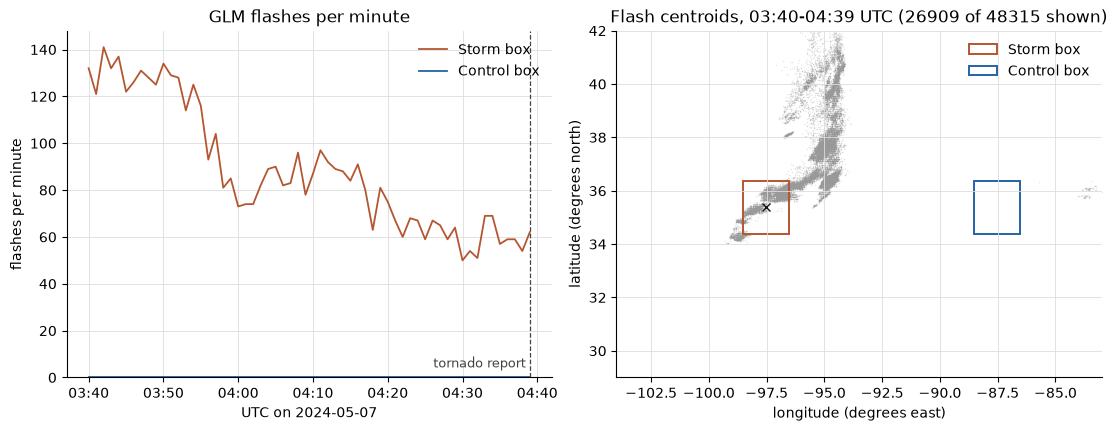

In [7]:
%matplotlib inline
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")
axes[0].plot(counts.index, counts.storm_box, color="#b45631", linewidth=1.3, label="Storm box")
axes[0].plot(counts.index, counts.control_box, color="#2563a6", linewidth=1.3, label="Control box")
axes[0].axvline(REPORT_UTC, color="#444444", linewidth=0.9, linestyle="--")
axes[0].text(REPORT_UTC, 3, "tornado report ", ha="right", va="bottom", fontsize=9, color="#444444")
axes[0].set(
    title="GLM flashes per minute",
    ylabel="flashes per minute",
    xlabel="UTC on 2024-05-07",
    ylim=(0, None),
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[0].legend(loc="upper right", frameon=False)

region = flashes[flashes.flash_lat.between(29, 42) & flashes.flash_lon.between(-104, -83)]
axes[1].scatter(
    region.flash_lon, region.flash_lat, s=1.0, color="#999999", alpha=0.25, linewidths=0
)
for lat, lon, color, label in (
    (REPORT_LAT, REPORT_LON, "#b45631", "Storm box"),
    (CONTROL_LAT, CONTROL_LON, "#2563a6", "Control box"),
):
    axes[1].add_patch(
        Rectangle(
            (lon - HALF_DEGREES, lat - HALF_DEGREES),
            2 * HALF_DEGREES,
            2 * HALF_DEGREES,
            fill=False,
            edgecolor=color,
            linewidth=1.4,
            label=label,
        )
    )
axes[1].plot(REPORT_LON, REPORT_LAT, marker="x", color="#111111", markersize=6)
axes[1].set(
    title=f"Flash centroids, 03:40-04:39 UTC ({len(region)} of {len(flashes)} shown)",
    xlabel="longitude (degrees east)",
    ylabel="latitude (degrees north)",
    xlim=(-104, -83),
    ylim=(29, 42),
)
axes[1].legend(loc="upper right", frameon=False)
for ax in axes:
    ax.grid(color="#dddddd", linewidth=0.6)
    ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 7. What the counts do not show

A flash count is not a measure of storm intensity. GLM records optical pulses
that reach cloud top, so its detection efficiency varies with viewing angle,
cloud depth, the size and brightness of a flash, and the background scene; a
flash centroid is a cloud-top position, not a ground strike, and a large flash
covering several counties counts once. The box is a fixed square around one
reported point, not a storm outline, and it neither moves with the storm nor
separates one storm from another.

The comparison is one hour of one case. A control box that held nothing says
what a same-size box elsewhere held that hour; it is not a null distribution,
and nothing here estimates how often a falling flash rate precedes a tornado
report. No published lightning-jump measure is computed or tested. The report
time is the beginning of a reported path recorded to the minute in local
standard time, and its uncertainty is not represented in the series.

In [8]:
print(
    f"Flashes in the storm box fell from {first_ten:.0f} per minute over the first ten minutes "
    f"of the hour to {last_ten:.0f} per minute over the ten minutes ending at the report, "
    f"a change of {100 * (last_ten - first_ten) / first_ten:.0f}%."
)
print(
    f"Over the same hour the whole field of view changed by "
    f"{100 * (field_last_ten - field_first_ten) / field_first_ten:.0f}%, so the box fell faster "
    "than the instrument's total."
)
print(
    f"The box still held {100 * len(storm) / len(flashes):.1f}% of the {len(flashes)} flashes "
    f"recorded anywhere in the field of view, rank {rank} of {len(grid)} two-degree cells, "
    f"while the control box ten degrees east held {len(control)}."
)
print("Scope: 180 GOES-16 GLM files, one hour, one reported tornado, counts only.")
again = pull(manifest)
print("Restored from lockfile:", again.from_lockfile)
print("All assets came from cache:", all(item.from_cache for item in again.fetched))

Flashes in the storm box fell from 130 per minute over the first ten minutes of the hour to 58 per minute over the ten minutes ending at the report, a change of -55%.
Over the same hour the whole field of view changed by -15%, so the box fell faster than the instrument's total.
The box still held 11.0% of the 48315 flashes recorded anywhere in the field of view, rank 2 of 189 two-degree cells, while the control box ten degrees east held 0.
Scope: 180 GOES-16 GLM files, one hour, one reported tornado, counts only.
Restored from lockfile: True
All assets came from cache: True
